In [ ]:
import sys
import numpy as np
import sklearn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# import the ICU Molecular Biology (Promoter Gene Sequences) Data Set
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data"

In [ ]:
names = ["Class", "id", "Sequence"]

In [ ]:
data = pd.read_csv(url, names = names)

In [ ]:
data

,Class,id,Sequence
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...
...,...,...,...
101,-,799,\t\tcctcaatggcctctaaacgggtcttgaggggttttttgctga...
102,-,987,\t\tgtattctcaacaagattaaccgacagattcaatctcgtggat...
103,-,1226,\t\tcgcgactacgatgagatgcctgagtgcttccgttactggatt...
104,-,794,\t\tctcgtcctcaatggcctctaaacgggtcttgaggggtttttt...


"+" means the promoters
"-" means is anything that is not promoters.

In [ ]:
classes = data.loc[:,"Class"]

In [ ]:
sequences = list(data.loc[: , "Sequence"])
dataset = {}

# loop hrough sequences and split into individual nucleotides
for i, seq in enumerate(sequences):

  # split into nucleotides, remove ta characters
  nucleotides = list(seq)
  nucleotides = [x for x in nucleotides if x != '\t']

  # append class assignment
  nucleotides.append(classes[i])

  # add to dataset
  dataset[i] = nucleotides

print(dataset[0])

['t', 'a', 'c', 't', 'a', 'g', 'c', 'a', 'a', 't', 'a', 'c', 'g', 'c', 't', 't', 'g', 'c', 'g', 't', 't', 'c', 'g', 'g', 't', 'g', 'g', 't', 't', 'a', 'a', 'g', 't', 'a', 't', 'g', 't', 'a', 't', 'a', 'a', 't', 'g', 'c', 'g', 'c', 'g', 'g', 'g', 'c', 't', 't', 'g', 't', 'c', 'g', 't', '+']


In [ ]:
# turn dataset into pandas DataFrame
dframe = pd.DataFrame(dataset)

# print the dataframe using tabulate packages in a tab-separated format
dframe

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
0,t,t,g,a,t,a,c,t,c,t,...,c,c,t,a,g,c,g,c,c,t
1,a,g,t,a,c,g,a,t,g,t,...,c,g,a,g,a,c,t,g,t,a
2,c,c,a,t,g,g,g,t,a,t,...,g,c,t,a,g,t,a,c,c,a
3,t,t,c,t,a,g,g,c,c,t,...,a,t,g,g,a,c,t,g,g,c
4,a,a,t,g,t,g,g,t,t,a,...,g,a,a,g,g,a,t,a,t,a
5,g,t,a,t,a,c,g,a,t,a,...,t,g,c,g,c,a,c,c,c,t
6,c,c,g,g,a,a,g,c,a,a,...,a,g,c,t,a,t,t,t,c,t
7,a,c,a,a,t,a,t,a,a,t,...,g,a,g,g,t,g,c,a,t,a
8,a,t,g,t,t,g,g,a,t,t,...,a,c,a,t,g,g,a,c,c,a
9,t,g,a,g,a,g,g,a,a,t,...,c,t,a,a,t,c,a,g,a,t


In [ ]:
# transpose the dataframe
df = dframe.transpose()

# print the dataframe using tabulate packages in a tab-separated format
df.iloc[:5]

df.rename(columns = {57 : "Class"}, inplace = True)
df

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Class
0,t,a,c,t,a,g,c,a,a,t,...,g,c,t,t,g,t,c,g,t,+
1,t,g,c,t,a,t,c,c,t,g,...,c,a,t,c,g,c,c,a,a,+
2,g,t,a,c,t,a,g,a,g,a,...,c,a,c,c,c,g,g,c,g,+
3,a,a,t,t,g,t,g,a,t,g,...,a,a,c,a,a,a,c,t,c,+
4,t,c,g,a,t,a,a,t,t,a,...,c,c,g,t,g,g,t,a,g,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,c,c,t,c,a,a,t,g,g,c,...,g,a,a,c,t,a,t,a,t,-
102,g,t,a,t,t,c,t,c,a,a,...,t,c,a,a,c,a,t,t,g,-
103,c,g,c,g,a,c,t,a,c,g,...,a,a,g,g,c,t,t,c,c,-
104,c,t,c,g,t,c,c,t,c,a,...,a,g,g,a,g,g,a,a,c,-


In [ ]:
from sklearn import model_selection
from sklearn.preprocessing import LabelEncoder

# Create X and Y datasets for training
X = np.array(df.drop(['Class'],axis=1))
y = np.array(df['Class'])

# One-hot encode the nucleotide sequences
X = pd.get_dummies(pd.DataFrame(X)).values

# Encode the class labels to a single column with binary values
le = LabelEncoder()
y = le.fit_transform(y)

# define seed for reproducibility
seed = 1

# split data into training and testing datasets
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, random_state=seed)

In [ ]:
# Import necessary libraries
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Define scoring method
scoring = 'accuracy'

# Define the model to train
names = ["Nearest Neighbors", "Gaussian Process", "Decision Tree", "Random Forest",
         "Neural Net", "AdaBoost", "Naive Bayes", "SVM Linear", "SVM RBF", "SVM Sigmoid"]

classifiers = [
    KNeighborsClassifier(n_neighbors=3),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1),
    AdaBoostClassifier(),
    GaussianNB(),
    SVC(kernel='linear'),
    SVC(kernel='rbf'),
    SVC(kernel='sigmoid')
]

models = zip(names, classifiers)

# Evaluate each model in turn
results = []
for name, model in models:
    kfold = model_selection.KFold(n_splits=10)
    cv_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring, error_score='raise')
    results.append(cv_results)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(name)
    print(classification_report(y_test, predictions))

Nearest Neighbors: 0.825000 (0.127475)
Nearest Neighbors
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        10
           1       1.00      0.65      0.79        17

    accuracy                           0.78        27
   macro avg       0.81      0.82      0.78        27
weighted avg       0.86      0.78      0.78        27

Gaussian Process: 0.873214 (0.056158)
Gaussian Process
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.82      0.90        17

    accuracy                           0.89        27
   macro avg       0.88      0.91      0.89        27
weighted avg       0.91      0.89      0.89        27

Decision Tree: 0.708929 (0.176786)
Decision Tree
              precision    recall  f1-score   support

           0       0.56      1.00      0.71        10
           1       1.00      0.53      0.69        17

    accuracy         

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Neural Net: 0.887500 (0.087500)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Net
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.88      0.94        17

    accuracy                           0.93        27
   macro avg       0.92      0.94      0.92        27
weighted avg       0.94      0.93      0.93        27

AdaBoost: 0.885714 (0.104185)
AdaBoost
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.82      0.90        17

    accuracy                           0.89        27
   macro avg       0.88      0.91      0.89        27
weighted avg       0.91      0.89      0.89        27

Naive Bayes: 0.837500 (0.137500)
Naive Bayes
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.88      0.94        17

    accuracy                           0.93        27
   macro avg       0.92      0.94

In [7]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Define seed for reproducibility
seed = 1

# Safely load the dataframe and reconstruct X
try:
    _ = X
except NameError:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data"
    names = ["Class", "id", "Sequence"]
    data = pd.read_csv(url, names=names)
    classes = data.loc[:, "Class"]
    sequences = list(data.loc[:, "Sequence"])
    dataset = {}
    for i, seq in enumerate(sequences):
        nucleotides = list(seq)
        nucleotides = [x for x in nucleotides if x != '\t']
        nucleotides.append(classes[i])
        dataset[i] = nucleotides
    dframe = pd.DataFrame(dataset)
    df = dframe.transpose()
    df.rename(columns={57: "Class"}, inplace=True)
    X_temp = np.array(df.drop(['Class'], axis=1))
    X = pd.get_dummies(pd.DataFrame(X_temp)).values

# Initialize KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=seed, n_init='auto')

# Fit the model and predict the cluster assignments for X
clusters = kmeans.fit_predict(X)

# Display the cluster assignments
print("Cluster assignments for each sequence:")
print(clusters)

Cluster assignments for each sequence:
[1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 0 1
 0 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 1 0]


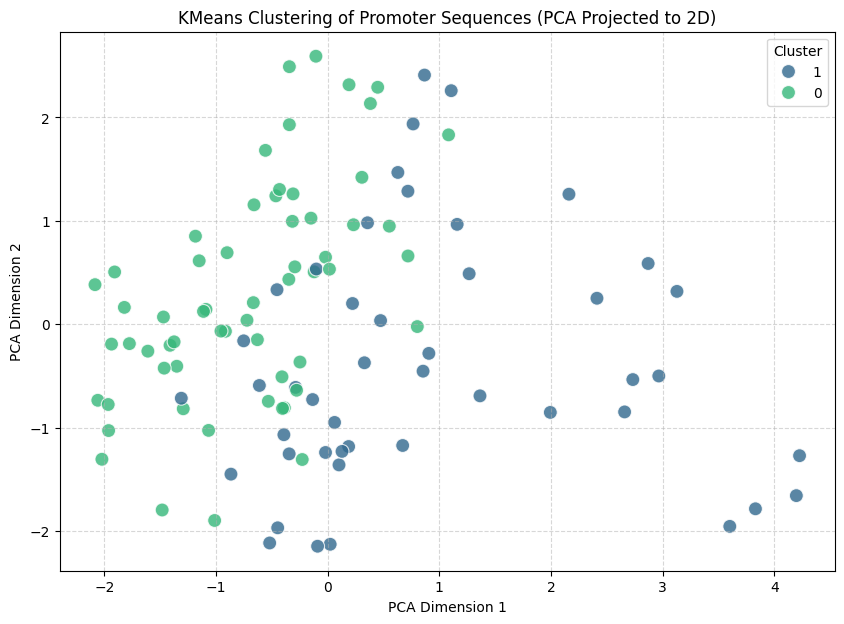

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce features to 2 dimensions using PCA
pca = PCA(n_components=2, random_state=seed)
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization
plot_df = pd.DataFrame(X_pca, columns=['PCA Dimension 1', 'PCA Dimension 2'])
plot_df['Cluster'] = clusters.astype(str)

# Plot the clustered data
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA Dimension 1',
    y='PCA Dimension 2',
    hue='Cluster',
    palette='viridis',
    data=plot_df,
    s=100,
    alpha=0.8
)

plt.title('KMeans Clustering of Promoter Sequences (PCA Projected to 2D)')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

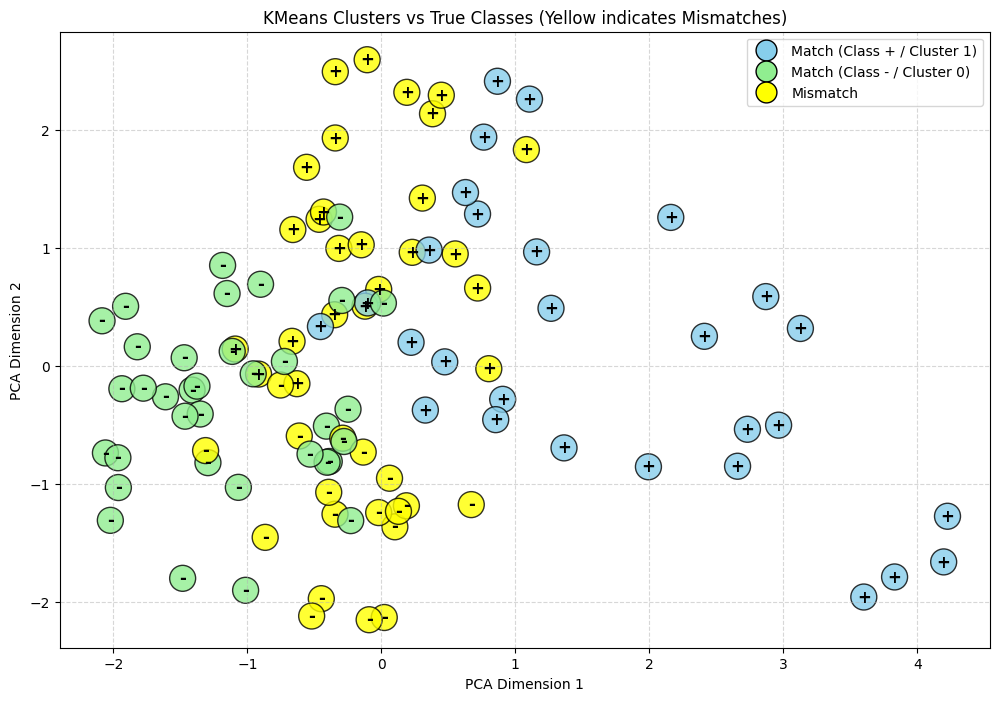

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare the plotting DataFrame
plot_df = pd.DataFrame(X_pca, columns=['PCA Dimension 1', 'PCA Dimension 2'])
plot_df['Cluster'] = clusters
plot_df['True Class'] = list(df['Class'])

# Define the matching rule:
# If True Class is '+' and Cluster is 1 -> Match (Group A)
# If True Class is '-' and Cluster is 0 -> Match (Group B)
# Otherwise -> Mismatch (Color Yellow)

colors = []
for idx, row in plot_df.iterrows():
    if (row['True Class'] == '+' and row['Cluster'] == 1):
        colors.append('skyblue')       # Matching Group A
    elif (row['True Class'] == '-' and row['Cluster'] == 0):
        colors.append('lightgreen')     # Matching Group B
    else:
        colors.append('yellow')         # Mismatch

plot_df['Color'] = colors

plt.figure(figsize=(12, 8))

# Draw the scatter plot with custom color mapping
plt.scatter(
    plot_df['PCA Dimension 1'],
    plot_df['PCA Dimension 2'],
    c=plot_df['Color'],
    s=350,
    alpha=0.8,
    edgecolors='black'
)

# Annotate each point with its True Class label
for i in range(len(plot_df)):
    plt.text(
        plot_df.loc[i, 'PCA Dimension 1'],
        plot_df.loc[i, 'PCA Dimension 2'],
        plot_df.loc[i, 'True Class'],
        color='black',
        ha='center',
        va='center',
        fontweight='bold',
        fontsize=12
    )

plt.title('KMeans Clusters vs True Classes (Yellow indicates Mismatches)')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Match (Class + / Cluster 1)', markerfacecolor='skyblue', markersize=15, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Match (Class - / Cluster 0)', markerfacecolor='lightgreen', markersize=15, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Mismatch', markerfacecolor='yellow', markersize=15, markeredgecolor='black')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()